# SBI Diagnostics

Diagnostics for Battaglia SBI datasets with one or more seed/lightcone realizations and optional SBI training outputs. Update the paths in the configuration cell if your cluster output directory differs.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})
import torch

In [2]:
import os
print (os.getcwd())

/home/cbllover/HalfDome/SBI_analysis


In [225]:
Path("../emulator_tSZ/outputs/binned_16e3_16/HalfDome_outputs/sbi16e3_bin16_dataset_100_000.npz").exists()

False

## Configuration

In [226]:
# Preferred cluster outputs from the SBI dataset combine scripts.

Ndata = 4096
dataset_seeds = "y100"
# DATASET_PATH = Path(f"/lustre/work/kristero10/tSZ_data/sbi_battaglia_{dataset_seeds}_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz")
DATASET_PATH = Path("../emulator_tSZ/outputs/binned_16e3_16/sbi16e3_bin16_dataset_100_000.npz")

# METADATA_PATH = DATASET_PATH.with_name(f"sbi_battaglia_{dataset_seeds}_{Ndata}_metadata.csv")
METADATA_PATH = DATASET_PATH.with_name("sbi16e3_bin16_dataset_100_000_metadata.csv")

# MANIFEST_PATH = DATASET_PATH.with_name(f"sbi_battaglia_{dataset_seeds}_{Ndata}_manifest.json")

MANIFEST_PATH = DATASET_PATH.with_name("sbi16e3_bin16_dataset_100_000_manifest.json")


# Optional SBI training output directory. Change this after running train_sbi.py.
SBI_OUTPUT_DIR = Path(f"outputs/posteriors")
NOTEBOOK_SBI_OUTPUT_DIR = SBI_OUTPUT_DIR / "notebook_training"
SAVE_NOTEBOOK_TRAINING_OUTPUTS = True

# Local fallbacks are useful when this notebook is run from SBI_analysis on the workstation copy.
# LOCAL_FALLBACKS = [
#     Path(f"../HPC_output/HalfDome/ydata_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz"),
#     Path(f"../HPC_output/HalfDome/ydata_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz"),
#     Path(f"../HPC_output/HalfDome/Emulator/y100_y102_N256_trials1500/combined_battaglia_profiles.npz"),
# ]

LOCAL_FALLBACKS = [
    Path(f"../emulator_tSZ/outputs/binned_16e3_16/HalfDome_outputs/sbi16e3_bin16_dataset_100_000.npz"),
    Path(f"../HPC_output/HalfDome/ydata_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz"),
    Path(f"../HPC_output/HalfDome/Emulator/y100_y102_N256_trials1500/combined_battaglia_profiles.npz"),
]


if not DATASET_PATH.exists():
    DATASET_PATH = next((p for p in LOCAL_FALLBACKS if p.exists()), DATASET_PATH)
    METADATA_PATH = DATASET_PATH.with_name(DATASET_PATH.stem + "_metadata.csv")
    MANIFEST_PATH = DATASET_PATH.with_name(DATASET_PATH.stem + "_manifest.json")

EXPECTED_POINTS = Ndata
ELL_MIN = 2
ELL_MAX = 4096
SAVE_FIGURES = False
FIGURE_DIR = Path("diagnostic_figures")

print(f"Dataset:  {DATASET_PATH}")
print(f"Metadata: {METADATA_PATH if METADATA_PATH.exists() else '<not found>'}")
print(f"Manifest: {MANIFEST_PATH if MANIFEST_PATH.exists() else '<not found>'}")
print(f"SBI dir:  {SBI_OUTPUT_DIR}")
print(f"Notebook training dir: {NOTEBOOK_SBI_OUTPUT_DIR}")

Dataset:  ../emulator_tSZ/outputs/binned_16e3_16/sbi16e3_bin16_dataset_100_000.npz
Metadata: <not found>
Manifest: <not found>
SBI dir:  outputs/posteriors
Notebook training dir: outputs/posteriors/notebook_training


## Load Dataset

In [243]:
from pathlib import Path
import json
import numpy as np

def as_str_list(arr):
    return [str(x) for x in np.asarray(arr).reshape(-1)]

def load_battaglia_dataset(path: Path) -> dict:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    with np.load(path, allow_pickle=True) as data:
        keys = set(data.files)
        print("keys:", keys)

        ell = np.asarray(data["ell"], dtype=float).reshape(-1)

        mask = ell >= ELL_MIN
        if ELL_MAX is not None:
            mask &= ell <= ELL_MAX

        # -------------------------------------------------
        # Case 1: already-built SBI dataset: theta + x
        # -------------------------------------------------
        if {"theta", "x", "ell", "theta_columns"}.issubset(keys):
            schema = "sbi_binned_dataset"

            theta = np.asarray(data["theta"], dtype=float)
            columns = as_str_list(data["theta_columns"])

            # Choose which data vector to load
            # x is usually the training vector
            x = np.asarray(data["x"], dtype=float)

            # Optional physical log10(D_ell) vector, if present
            if "x_log10_dl" in keys:
                x_log10_dl = np.asarray(data["x_log10_dl"], dtype=float)
            else:
                x_log10_dl = None

            if x.shape[1] != ell.shape[0]:
                raise ValueError(
                    f"x has {x.shape[1]} bins but ell has {ell.shape[0]} values"
                )

            x = x[:, mask]

            if x_log10_dl is not None:
                x_log10_dl = x_log10_dl[:, mask]

            seed_spectra = {}

            dataset = {
                "path": path,
                "schema": schema,
                "keys": sorted(keys),
                "theta": theta,
                "columns": columns,
                "ell": ell[mask],
                "x": x,
                "x_log10_dl": x_log10_dl,
                "cl_mean": x,   # compatibility alias; note this is not raw C_l
                "seed_names": [],
                "seed_spectra": {},
            }

            # Optional metadata
            for k in [
                "bin_ell_min",
                "bin_ell_max",
                "bin_counts",
                "prior_low",
                "prior_high",
                "target_kind",
                "source_emulator",
            ]:
                if k in keys:
                    dataset[k] = data[k]

            return dataset

        # -------------------------------------------------
        # Case 2: raw spectra dataset with theta + cl arrays
        # -------------------------------------------------
        elif {"theta", "ell", "theta_columns"}.issubset(keys):
            schema = "raw_cl_dataset"

            theta = np.asarray(data["theta"], dtype=float)
            columns = as_str_list(data["theta_columns"])

            seed_keys = sorted(
                (key for key in keys if key.startswith("cl_y")),
                key=seed_sort_key
            )

            seed_spectra = {
                seed_label_from_key(key): np.asarray(data[key], dtype=float)[:, mask]
                for key in seed_keys
            }

            if seed_spectra:
                cl_mean = mean_seed_spectra(seed_spectra)

            elif "cl_stack" in keys:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)

                if cl_stack.ndim != 3:
                    raise ValueError(
                        f"Expected cl_stack with shape (n, n_seeds, ell), got {cl_stack.shape}"
                    )

                if "seed_ids" in keys:
                    seed_labels = [
                        f"y{int(seed)}"
                        for seed in np.asarray(data["seed_ids"]).reshape(-1)
                    ]
                else:
                    seed_labels = [
                        f"seed_{idx}" for idx in range(cl_stack.shape[1])
                    ]

                seed_spectra = {
                    label: cl_stack[:, idx, :][:, mask]
                    for idx, label in enumerate(seed_labels)
                }

                cl_mean = mean_seed_spectra(seed_spectra)

            elif "cl_mean" in keys:
                cl_mean = np.asarray(data["cl_mean"], dtype=float)[:, mask]
                seed_spectra = {}

            else:
                raise KeyError(
                    f"{path} has no C_l arrays matching cl_y*, cl_stack, or cl_mean"
                )

            if theta.shape[0] != cl_mean.shape[0]:
                raise ValueError(
                    f"theta rows {theta.shape[0]} and cl_mean rows {cl_mean.shape[0]} do not match"
                )

            dataset = {
                "path": path,
                "schema": schema,
                "keys": sorted(keys),
                "theta": theta,
                "columns": columns,
                "ell": ell[mask],
                "cl_mean": cl_mean,
                "x": cl_mean,
                "seed_names": list(seed_spectra),
                "seed_spectra": seed_spectra,
            }

            for name, values in seed_spectra.items():
                dataset[f"cl_{name}"] = values

            return dataset

        else:
            raise KeyError(f"Unsupported dataset schema. Keys: {sorted(keys)}")

In [254]:
dataset = load_battaglia_dataset(DATASET_PATH)

theta = dataset["theta"]
ell = dataset["ell"]
x = dataset["x"]
cl_mean = x
print (dataset["schema"])
print(theta.shape, ell.shape, x.shape)

keys: {'x', 'binning_json', 'theta', 'ell', 'prior_high', 'theta_columns', 'bin_ell_max', 'prior_bounds_json', 'target_kind', 'bin_counts', 'source_emulator', 'x_log10_dl', 'bin_ell_min', 'prior_low'}
sbi_binned_dataset
(100000, 9) (16,) (100000, 16)


## Basic Integrity Checks

In [255]:
def count_nonfinite(name, values):
    n_bad = int((~np.isfinite(values)).sum())
    print(f"{name:10s} non-finite: {n_bad}")
    return n_bad


print(f"Expected points: {EXPECTED_POINTS}")
print(f"Actual points:   {theta.shape[0]}")
if theta.shape[0] != EXPECTED_POINTS:
    print("WARNING: dataset point count does not match EXPECTED_POINTS")

count_nonfinite("theta", theta)
count_nonfinite("cl_mean", cl_mean)
for seed_name, values in seed_spectra.items():
    count_nonfinite(f"cl_{seed_name}", values)

arrays_to_summarize = [("cl_mean", cl_mean)] + [(f"cl_{seed_name}", values) for seed_name, values in seed_spectra.items()]
for name, values in arrays_to_summarize:
    finite = values[np.isfinite(values)]
    print(
        f"{name:10s} min={finite.min():.4e} median={np.median(finite):.4e} "
        f"max={finite.max():.4e} max_abs={np.max(np.abs(finite)):.4e}"
    )

if seed_spectra:
    seed_average = mean_seed_spectra(seed_spectra)
    print(
        f"mean equals average of {len(seed_spectra)} loaded seed(s):",
        np.allclose(cl_mean, seed_average, rtol=1e-7, atol=0.0),
    )
else:
    print("No individual seed spectra were loaded; cl_mean was read directly.")

Expected points: 4096
Actual points:   100000
theta      non-finite: 0
cl_mean    non-finite: 0
cl_y100    non-finite: 0
cl_mean    min=-1.9390e+01 median=-1.2913e+01 max=-8.7022e+00 max_abs=1.9390e+01
cl_y100    min=8.6401e-24 median=1.2727e-18 max=1.1880e-12 max_abs=1.1880e-12


ValueError: operands could not be broadcast together with shapes (100000,16) (4096,4095) 

In [253]:
cl_mean.shape

(4096, 4095)

## Metadata And Split Coverage

In [246]:
metadata = None
manifest = None

if METADATA_PATH.exists():
    metadata = pd.read_csv(METADATA_PATH)
    display(metadata.head())
    print("metadata rows:", len(metadata))
    for col in ["sobol_split", "sobol_row", "sobol_global_row", "y100_n", "y102_n", "param_key"]:
        if col in metadata.columns:
            print(f"{col}: present")
    if "sobol_split" in metadata.columns:
        display(metadata["sobol_split"].value_counts().sort_index().rename("rows_per_split").to_frame())
    if "sobol_global_row" in metadata.columns:
        duplicates = metadata[metadata["sobol_global_row"].duplicated(keep=False)]
        print("duplicate sobol_global_row rows:", len(duplicates))
        expected = set(range(1, EXPECTED_POINTS + 1))
        actual = set(metadata["sobol_global_row"].astype(int))
        missing = sorted(expected - actual)
        extra = sorted(actual - expected)
        print("missing global rows:", missing[:20], "count=", len(missing))
        print("extra global rows:", extra[:20], "count=", len(extra))
    if {"y100_n", "y102_n"}.issubset(metadata.columns):
        display(metadata[["y100_n", "y102_n"]].value_counts().rename("count").to_frame())
else:
    print("Metadata CSV not found; skipping metadata checks.")

if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print(json.dumps(manifest, indent=2)[:3000])
else:
    print("Manifest JSON not found; skipping manifest display.")

Metadata CSV not found; skipping metadata checks.
Manifest JSON not found; skipping manifest display.


## Parameter Coverage

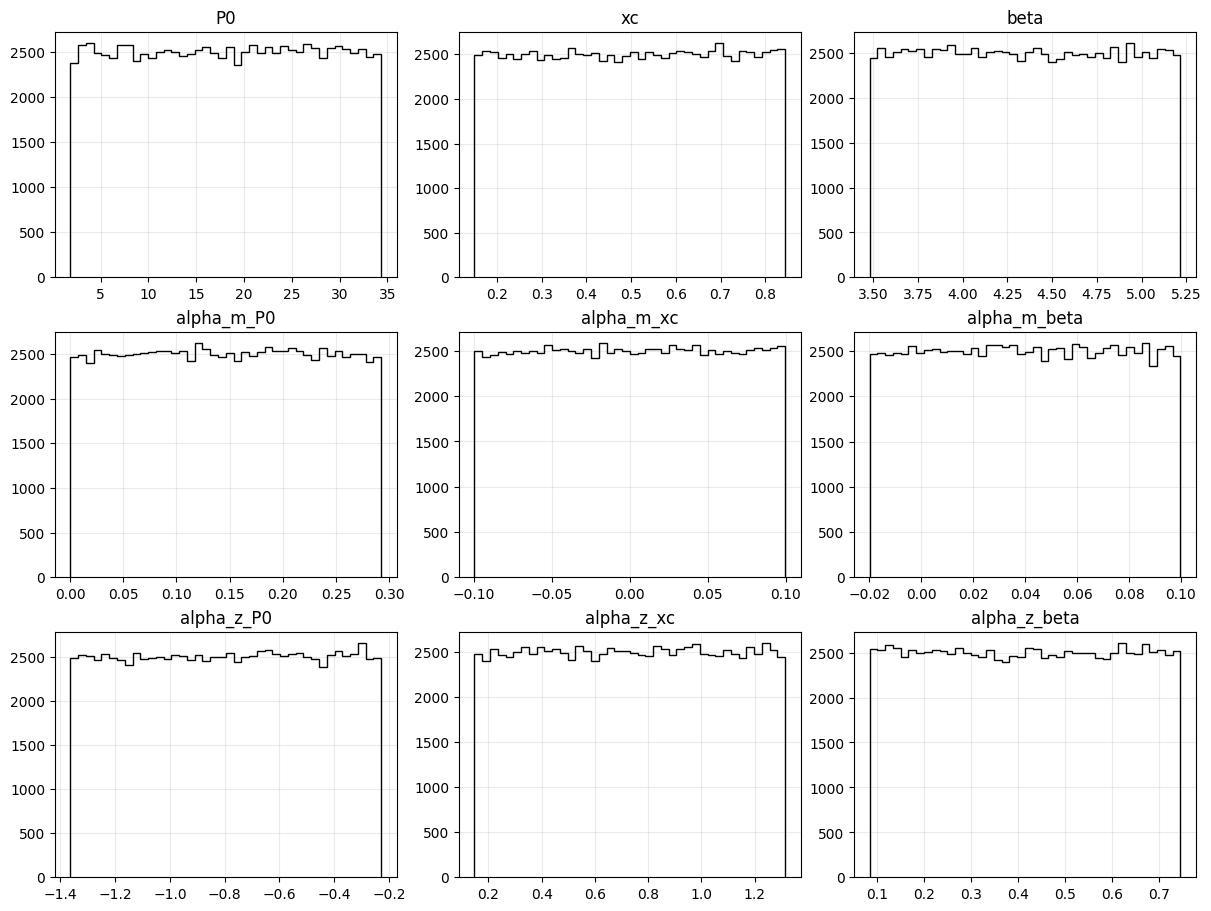

In [247]:
ncols = 3
nrows = math.ceil(len(columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
for idx, name in enumerate(columns):
    axes[idx].hist(theta[:, idx], bins=40, histtype="step", color="black")
    axes[idx].set_title(name)
for ax in axes[len(columns):]:
    ax.axis("off")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / "parameter_coverage.png", dpi=180)
plt.show()

In [248]:
param_summary = pd.DataFrame(theta, columns=columns).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(param_summary)

,count,mean,std,min,1%,5%,50%,95%,99%,max
P0,100000.0,18.114249,9.382163,1.833129,2.161399,3.476076,18.149503,32.686851,34.004511,34.341152
xc,100000.0,0.498102,0.200816,0.150011,0.157088,0.184630,0.498982,0.810525,0.837535,0.844492
beta,100000.0,4.347190,0.501651,3.480649,3.497835,3.567375,4.345964,5.130009,5.198810,5.216601
alpha_m_P0,100000.0,0.146330,0.084004,0.000329,0.003372,0.015048,0.146290,0.277322,0.289280,0.292250
alpha_m_xc,100000.0,0.000279,0.057570,-0.099718,-0.097846,-0.089587,0.000306,0.089988,0.097866,0.099795
alpha_m_beta,100000.0,0.039935,0.034494,-0.019934,-0.018715,-0.013885,0.039844,0.093776,0.098561,0.099766
alpha_z_P0,100000.0,-0.794670,0.327709,-1.363449,-1.352178,-1.306746,-0.793302,-0.286060,-0.239867,-0.228839
alpha_z_xc,100000.0,0.731827,0.336538,0.147394,0.159368,0.207230,0.731953,1.255861,1.302190,1.314433
alpha_z_beta,100000.0,0.414512,0.191776,0.083809,0.090277,0.116489,0.415191,0.712673,0.739242,0.745864


## Spectrum Coverage

In [249]:
def cl_to_log10_dl(cl, ell, floor=1.0e-40):
    factor = ell * (ell + 1.0) / (2.0 * np.pi)
    return np.log10(np.maximum(np.asarray(cl) * factor, floor))


# Preserve the full-resolution data vector. The next section defines the active
# binned version used by every diagnostic and SBI training cell below.
ell_unbinned = np.ascontiguousarray(ell, dtype=np.float32)
x_mean_unbinned = np.ascontiguousarray(cl_to_log10_dl(cl_mean, ell_unbinned), dtype=np.float32)
x_by_seed_unbinned = {
    seed_name: np.ascontiguousarray(cl_to_log10_dl(values, ell_unbinned), dtype=np.float32)
    for seed_name, values in seed_spectra.items()
}

if len(seed_names) == 1:
    spectrum_label = seed_names[0]
elif seed_names:
    spectrum_label = f"mean of {len(seed_names)} seeds"
else:
    spectrum_label = "cl_mean"

print("unbinned x_mean:", x_mean_unbinned.shape)
print("unbinned ell:", ell_unbinned.shape, float(ell_unbinned[0]), float(ell_unbinned[-1]))


ValueError: operands could not be broadcast together with shapes (4096,4095) (16,) 

## Datavector Binning

The active SBI datavector is binned before diagnostics and training. The default is 256 logarithmic ell bins. Edit `DATAVECTOR_BINNING` to change the number of bins, use linear/custom binning, or switch the statistic/weighting.


In [256]:
DATAVECTOR_BINNING = {
    "enabled": False,
    "mode": "log",             # "log", "linear", or "custom"
    "n_bins": 32,
    "ell_min": ELL_MIN,
    "ell_max": ELL_MAX,
    "custom_edges": None,      # e.g. [2, 10, 20, 50, 100, 200, 500, 1000, 2000, 4096]
    "statistic": "mean",       # "mean" or "median"
    "weighting": "uniform",    # "uniform", "ell", or "2ell_plus_1"
}


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _make_bin_edges(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    ell_min = float(config.get("ell_min", np.nanmin(ell_values)))
    ell_max = float(config.get("ell_max", np.nanmax(ell_values)))
    ell_min = max(ell_min, float(np.nanmin(ell_values)))
    ell_max = min(ell_max, float(np.nanmax(ell_values)))
    if not ell_max > ell_min:
        raise ValueError(f"Need ell_max > ell_min for binning, got {ell_min} and {ell_max}")

    mode = str(config.get("mode", "log")).lower()
    if mode == "custom" or config.get("custom_edges") is not None:
        edges = np.asarray(config["custom_edges"], dtype=np.float64)
        if edges.ndim != 1 or edges.size < 2:
            raise ValueError("custom_edges must be a one-dimensional sequence with at least two values")
    else:
        n_bins = int(config.get("n_bins", 32))
        if n_bins < 1:
            raise ValueError("n_bins must be positive")
        if mode == "log":
            if ell_min <= 0:
                raise ValueError("log binning requires ell_min > 0")
            edges = np.geomspace(ell_min, ell_max, n_bins + 1)
        elif mode == "linear":
            edges = np.linspace(ell_min, ell_max, n_bins + 1)
        else:
            raise ValueError("mode must be 'log', 'linear', or 'custom'")

    edges = np.asarray(edges, dtype=np.float64)
    edges = np.unique(edges)
    if edges.size < 2:
        raise ValueError("Binning edges collapsed to fewer than two unique values")
    if np.any(np.diff(edges) <= 0):
        raise ValueError("Binning edges must be strictly increasing")
    return edges


def _split_members_to_target(members, ell_values, target_n_bins):
    members = list(members)
    target_n_bins = int(target_n_bins)
    if target_n_bins <= len(members):
        return members

    log_ell = np.log(np.maximum(np.asarray(ell_values, dtype=np.float64), 1.0))
    while len(members) < target_n_bins:
        splittable = [i for i, idx in enumerate(members) if idx.size > 1]
        if not splittable:
            break

        def bin_width(i):
            idx = members[i]
            return log_ell[idx[-1]] - log_ell[idx[0]]

        widest = max(splittable, key=bin_width)
        idx = members[widest]
        midpoint = 0.5 * (log_ell[idx[0]] + log_ell[idx[-1]])
        split_at = int(np.searchsorted(log_ell[idx], midpoint, side="right"))
        split_at = min(max(split_at, 1), idx.size - 1)
        members[widest : widest + 1] = [idx[:split_at], idx[split_at:]]

    return members


def _summarize_bin_members(members, ell_values, weighting):
    centers = []
    counts = []
    bin_min = []
    bin_max = []
    for idx in members:
        weights = _bin_weights(ell_values[idx], weighting)
        centers.append(np.average(ell_values[idx], weights=weights))
        counts.append(idx.size)
        bin_min.append(ell_values[idx[0]])
        bin_max.append(ell_values[idx[-1]])
    return {
        "centers": np.asarray(centers, dtype=np.float32),
        "counts": np.asarray(counts, dtype=np.int64),
        "bin_min": np.asarray(bin_min, dtype=np.float32),
        "bin_max": np.asarray(bin_max, dtype=np.float32),
    }


def make_ell_binning(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = config.get("weighting", "uniform")
    if not bool(config.get("enabled", True)):
        members = [np.array([i], dtype=np.int64) for i in range(ell_values.size)]
        summary = _summarize_bin_members(members, ell_values, weighting)
        return {
            "enabled": False,
            "edges": None,
            "members": members,
            **summary,
        }

    edges = _make_bin_edges(ell_values, config)
    selected = (ell_values >= edges[0]) & (ell_values <= edges[-1])
    bin_index = np.digitize(ell_values, edges, right=False) - 1
    bin_index[ell_values == edges[-1]] = edges.size - 2

    members = []
    for i in range(edges.size - 1):
        idx = np.flatnonzero(selected & (bin_index == i))
        if idx.size:
            members.append(idx.astype(np.int64))

    if not members:
        raise ValueError("Binning produced no non-empty bins")

    mode = str(config.get("mode", "log")).lower()
    if mode != "custom" and config.get("custom_edges") is None:
        members = _split_members_to_target(members, ell_values, int(config.get("n_bins", len(members))))

    summary = _summarize_bin_members(members, ell_values, weighting)
    return {
        "enabled": True,
        "edges": edges.astype(np.float32),
        "members": members,
        **summary,
    }


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    ell_values = np.asarray(ell_values, dtype=np.float64)
    if values.shape[-1] != ell_values.size:
        raise ValueError(f"Last axis has length {values.shape[-1]}, expected {ell_values.size}")

    statistic = str(statistic).lower()
    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]
        if statistic == "mean":
            weights = _bin_weights(ell_values[idx], weighting)
            pieces.append(np.average(selected, axis=-1, weights=weights))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")
    return np.stack(pieces, axis=-1)


def binning_summary_to_jsonable(summary):
    out = {}
    for key, value in summary.items():
        if isinstance(value, np.ndarray):
            out[key] = value.tolist()
        elif isinstance(value, (np.integer, np.floating)):
            out[key] = value.item()
        else:
            out[key] = value
    return out


ell_binning = make_ell_binning(ell_unbinned, DATAVECTOR_BINNING)
if DATAVECTOR_BINNING["enabled"]:
    x_mean = np.ascontiguousarray(
        bin_last_axis(
            x_mean_unbinned,
            ell_binning,
            ell_unbinned,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_by_seed = {
        seed_name: np.ascontiguousarray(
            bin_last_axis(
                values,
                ell_binning,
                ell_unbinned,
                statistic=DATAVECTOR_BINNING["statistic"],
                weighting=DATAVECTOR_BINNING["weighting"],
            ),
            dtype=np.float32,
        )
        for seed_name, values in x_by_seed_unbinned.items()
    }
    ell = np.ascontiguousarray(ell_binning["centers"], dtype=np.float32)
else:
    x_mean = x_mean_unbinned
    x_by_seed = dict(x_by_seed_unbinned)
    ell = ell_unbinned

x_y100 = x_by_seed.get("y100")
x_y102 = x_by_seed.get("y102")

BINNING_SUMMARY = {
    "enabled": bool(DATAVECTOR_BINNING["enabled"]),
    "mode": DATAVECTOR_BINNING["mode"],
    "requested_n_bins": int(DATAVECTOR_BINNING["n_bins"]),
    "n_bins": int(ell.size),
    "statistic": DATAVECTOR_BINNING["statistic"],
    "weighting": DATAVECTOR_BINNING["weighting"],
    "ell_min": float(ell_binning["bin_min"][0]),
    "ell_max": float(ell_binning["bin_max"][-1]),
    "bin_counts": ell_binning["counts"],
    "bin_ell_min": ell_binning["bin_min"],
    "bin_ell_max": ell_binning["bin_max"],
    "bin_edges": ell_binning["edges"],
}

print(
    f"active datavector: {x_mean.shape[1]} bins "
    f"({DATAVECTOR_BINNING['mode']}, {DATAVECTOR_BINNING['statistic']}, {DATAVECTOR_BINNING['weighting']} weighting)"
)
print(f"ell centers: {ell[0]:.1f}-{ell[-1]:.1f}; bin counts: {ell_binning['counts'].min()}-{ell_binning['counts'].max()}")


active datavector: 32 bins (log, mean, uniform weighting)
ell centers: 23.5-1247.0; bin counts: 1-1


In [252]:
DATAVECTOR_BINNING["enabled"]

False

ValueError: 'x' has size 16, but 'y1' has an unequal size of 32

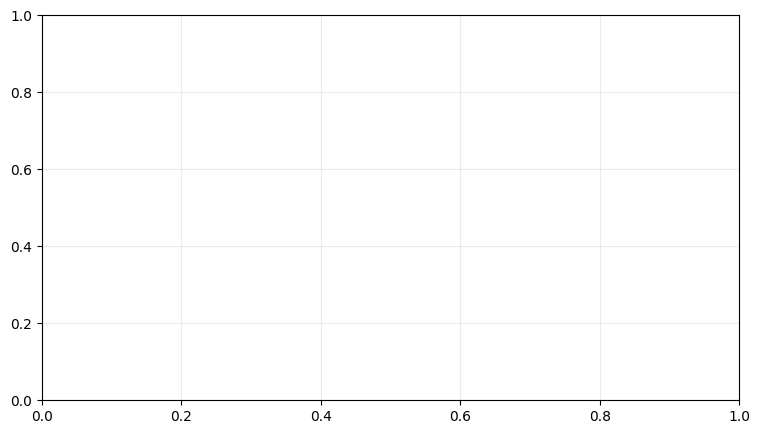

In [251]:
q16, q50, q84 = np.percentile(x_mean, [16, 50, 84], axis=0)
q01, q99 = np.percentile(x_mean, [1, 99], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(ell, q01, q99, alpha=0.15, label="1-99%")
ax.fill_between(ell, q16, q84, alpha=0.30, label="16-84%")
ax.plot(ell, q50, color="black", lw=1.5, label="median")
ax.set_xscale("log")
ax.set_xlabel("ell bin center" if BINNING_SUMMARY["enabled"] else "ell")
ax.set_ylabel("log10(D_ell)")
ax.set_title(f"{spectrum_label} spectrum coverage")
ax.legend()
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / "spectrum_coverage_log10_dl.png", dpi=180)
plt.show()


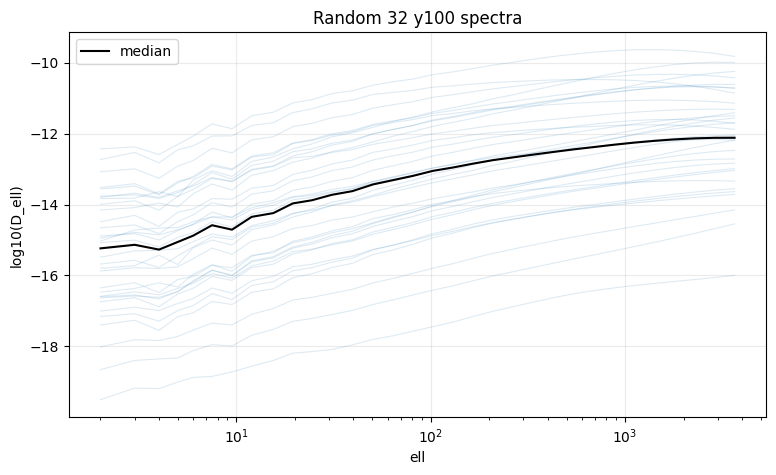

In [203]:
rng = np.random.default_rng(1234)
n_show = min(32, x_mean.shape[0])
chosen = rng.choice(x_mean.shape[0], size=n_show, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
for idx in chosen:
    ax.plot(ell, x_mean[idx], color="tab:blue", alpha=0.15, lw=0.8)
ax.plot(ell, q50, color="black", lw=1.5, label="median")
ax.set_xscale("log")
ax.set_xlabel("ell")
ax.set_ylabel("log10(D_ell)")
ax.set_title(f"Random {n_show} {spectrum_label} spectra")
ax.legend()
plt.show()

## Seed Scatter And Outliers

In [204]:
if len(x_by_seed) >= 2:
    x_seed_stack = np.stack(list(x_by_seed.values()), axis=0)
    seed_variance = np.nanvar(x_seed_stack, axis=0, ddof=1)
    sigma_single = np.sqrt(np.nanmean(seed_variance, axis=0))
    sigma_mean = sigma_single / np.sqrt(len(x_by_seed))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(ell, sigma_single, label="single seed")
    ax.plot(ell, sigma_mean, label=f"{len(x_by_seed)}-seed mean")
    ax.set_xscale("log")
    ax.set_xlabel("ell")
    ax.set_ylabel("sigma[log10(D_ell)]")
    ax.set_title("Empirical seed scatter")
    ax.legend()
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / "seed_scatter_log10_dl.png", dpi=180)
    plt.show()

    print("seed names:", seed_names)
    print("median sigma single:", float(np.nanmedian(sigma_single)))
    print("max sigma single:", float(np.nanmax(sigma_single)))
else:
    sigma_single = np.full_like(ell, np.nan, dtype=float)
    sigma_mean = np.full_like(ell, np.nan, dtype=float)
    print(f"Only {len(x_by_seed)} seed loaded; empirical seed scatter is not defined.")

Only 1 seed loaded; empirical seed scatter is not defined.


In [205]:
rms_diff = np.sqrt(np.nanmean(diff**2, axis=1))
max_abs_diff = np.nanmax(np.abs(diff), axis=1)
outlier_table = pd.DataFrame({
    "row_index": np.arange(theta.shape[0]),
    "rms_log10_diff": rms_diff,
    "max_abs_log10_diff": max_abs_diff,
})
if metadata is not None:
    for col in ["sobol_global_row", "sobol_split", "sobol_row", "param_key"]:
        if col in metadata.columns:
            outlier_table[col] = metadata[col].to_numpy()
display(outlier_table.sort_values("rms_log10_diff", ascending=False).head(20))

NameError: name 'diff' is not defined

## Optional SBI Run Outputs

In [206]:
summary_path = SBI_OUTPUT_DIR / "sbi_run_summary.json"
config_path = SBI_OUTPUT_DIR / "run_config.json"

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print(json.dumps(summary, indent=2))
else:
    print(f"No SBI summary found at {summary_path}")

if config_path.exists():
    run_config = json.loads(config_path.read_text())
    print("\nrun_config paths:")
    for key in ["combined_dataset_path", "emulator_artifact_path", "observed_spectrum_path", "output_dir"]:
        print(f"  {key}: {run_config.get(key)}")

No SBI summary found at outputs/posteriors/sbi_run_summary.json


In [207]:
theta.shape

(100000, 9)

posterior samples: (40000, 9)


,count,mean,std,min,5%,16%,50%,84%,95%,max
P0,40000.0,22.948551,4.426291,11.026507,16.198760,18.398556,22.619066,27.646422,30.956953,34.338749
xc,40000.0,0.492506,0.085613,0.271090,0.358060,0.404503,0.488442,0.581779,0.641222,0.788151
beta,40000.0,4.465875,0.331426,3.490504,3.919600,4.123460,4.464415,4.814920,5.021784,5.216303
alpha_m_P0,40000.0,0.219128,0.048075,0.007530,0.130052,0.169167,0.225810,0.269504,0.284387,0.292251
alpha_m_xc,40000.0,0.001851,0.034499,-0.099550,-0.056976,-0.033530,0.002759,0.037314,0.057040,0.099744
alpha_m_beta,40000.0,0.065155,0.017921,-0.006047,0.033884,0.046654,0.066067,0.084082,0.093082,0.099758
alpha_z_P0,40000.0,-0.876360,0.211309,-1.363435,-1.227789,-1.097841,-0.876912,-0.658967,-0.525788,-0.229257
alpha_z_xc,40000.0,0.594510,0.203859,0.147441,0.260599,0.376991,0.591506,0.807688,0.936598,1.215777
alpha_z_beta,40000.0,0.376172,0.125893,0.083858,0.180748,0.244299,0.369974,0.508335,0.594617,0.744957


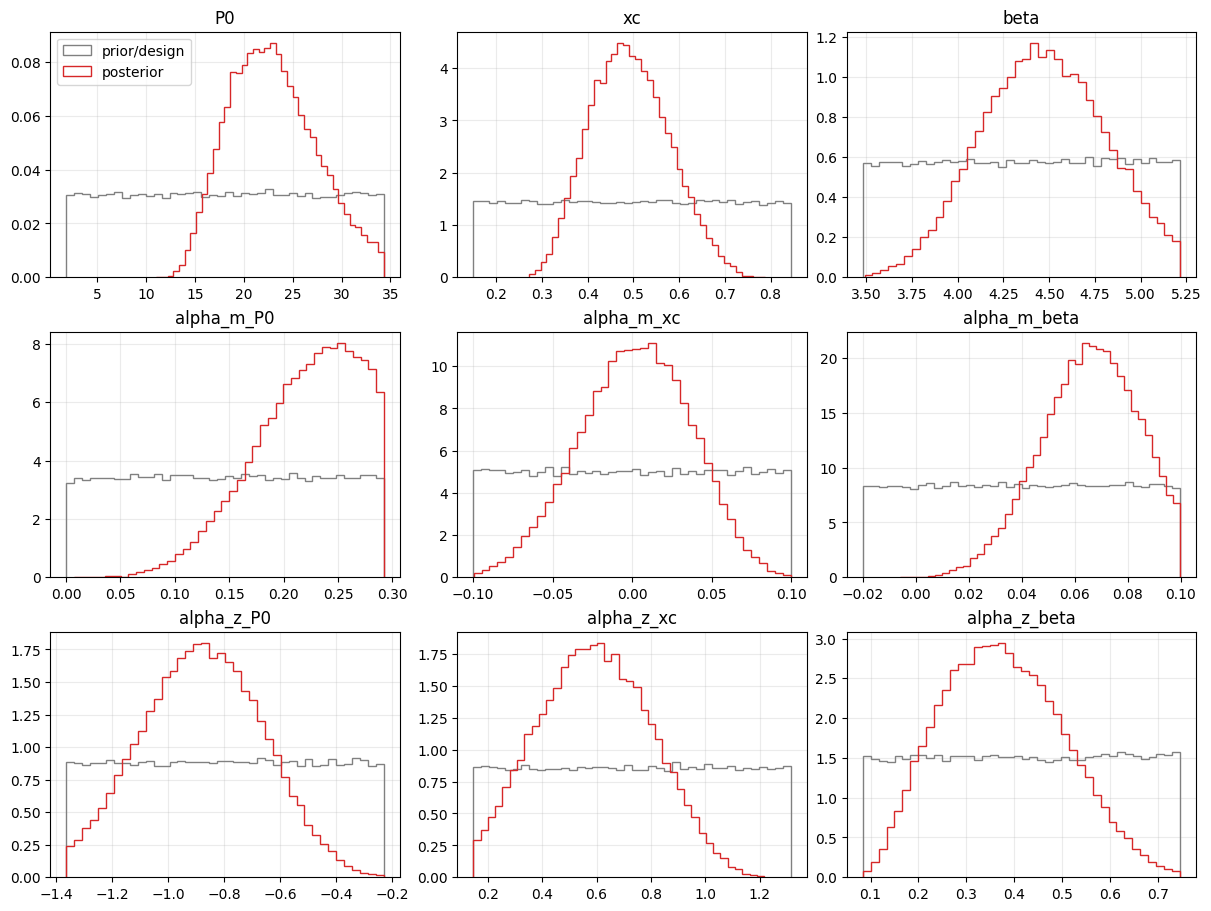

In [208]:
# posterior_path = SBI_OUTPUT_DIR / "gNFW_subsets/posterior_P0_A0_P0_alpha_m_P0_alpha_z_xc_A0_beta_A0_N4096_bins32_marginalized.npy"
posterior_path = SBI_OUTPUT_DIR / "posterior_100_000_emulator_sample_binned32_s40.npy"

# Must match the order inside posterior_samples, not the order in full theta/columns
# special_columns = ["P0", "alpha_m_P0", "alpha_z_P0", "xc", "beta"]  # None if all
special_columns = None
if posterior_path.exists():
    posterior_samples = np.load(posterior_path)
    print("posterior samples:", posterior_samples.shape)

    if special_columns is not None:
        if posterior_samples.shape[1] != len(special_columns):
            raise ValueError(
                f"posterior_samples has {posterior_samples.shape[1]} columns, "
                f"but special_columns has {len(special_columns)} names."
            )
        post_cols = special_columns
    else:
        post_cols = columns[:posterior_samples.shape[1]]

    post_df = pd.DataFrame(posterior_samples, columns=post_cols)

    display(post_df.describe(percentiles=[0.05, 0.16, 0.5, 0.84, 0.95]).T)

    # Map full design/prior columns to their indices in theta
    theta_col_index = {name: i for i, name in enumerate(columns)}

    missing = [name for name in post_df.columns if name not in theta_col_index]
    if missing:
        raise ValueError(f"Posterior columns not found in full theta columns: {missing}")

    n_params = len(post_df.columns)
    ncols = min(3, n_params)
    nrows = int(np.ceil(n_params / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(-1)

    for ax, name in zip(axes, post_df.columns):
        theta_idx = theta_col_index[name]

        ax.hist(
            theta[:, theta_idx],
            bins=40,
            density=True,
            histtype="step",
            color="0.5",
            label="prior/design",
        )
        ax.hist(
            post_df[name],
            bins=40,
            density=True,
            histtype="step",
            color="tab:red",
            label="posterior",
        )
        ax.set_title(name)

    axes[0].legend()

    for ax in axes[n_params:]:
        ax.axis("off")

    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / "posterior_1d_vs_design.png", dpi=180)

    plt.show()

else:
    posterior_samples = None
    print(f"No posterior samples found at {posterior_path}")

## Optional Emulator Validation Residuals

In [19]:
validation_path = SBI_OUTPUT_DIR / "emulator_dataset_validation.npz"
if validation_path.exists():
    val = np.load(validation_path, allow_pickle=True)
    residual = np.asarray(val["residual"], dtype=float)
    val_ell = np.asarray(val["ell"], dtype=float)
    p16, p50, p84 = np.percentile(residual, [16, 50, 84], axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(val_ell, p16, p84, alpha=0.25, label="16-84%")
    ax.plot(val_ell, p50, color="black", lw=1.5, label="median")
    ax.axhline(0.0, color="tab:red", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("ell")
    ax.set_ylabel("emulator - dataset [log10(D_ell)]")
    ax.set_title("Emulator validation residuals")
    ax.legend()
    plt.show()

    print("median abs residual:", float(np.median(np.abs(residual))))
    print("p84 abs residual:", float(np.percentile(np.abs(residual), 84)))
    print("max abs residual:", float(np.max(np.abs(residual))))
else:
    print(f"No emulator validation file found at {validation_path}")

No emulator validation file found at outputs/posteriors/emulator_dataset_validation.npz


SBI diagnostic


In [209]:
from sbi.inference import NPE
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot

In [210]:
def to_tensor(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().float()
    return torch.as_tensor(x, dtype=torch.float32)


def split_train_validation(prepared, n_train=850, n_val=174, seed=0):
    theta = to_tensor(prepared["theta"])
    x = to_tensor(prepared["x"])

    n_total = theta.shape[0]
    assert n_train + n_val <= n_total, "Not enough simulations."

    rng = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n_total, generator=rng)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]

    return {
        "theta_train": theta[train_idx],
        "x_train": x[train_idx],
        "theta_val": theta[val_idx],
        "x_val": x[val_idx],
        "train_idx": train_idx,
        "val_idx": val_idx,
    }

In [211]:
from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, save_pickle, selected_ell_mask, write_json
from sbi.utils import BoxUniform
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393,1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, columns)

prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))


prior = BoxUniform(low=prior_low_cpu, high=prior_high_cpu)


In [212]:
split["theta_train"].shape

torch.Size([3481, 9])

In [214]:
prepared = {
    "theta": theta,
    "x": x_mean,
    "ell": ell,
    "ell_unbinned": ell_unbinned,
    "binning": BINNING_SUMMARY,
}

split = split_train_validation(
    prepared,
    n_train=int(20000*0.85),
    n_val=int(20000*0.15),
    seed=42,
)

inference = NPE(prior=prior)

density_estimator = inference.append_simulations(
    split["theta_train"],
    split["x_train"],
).train()

posterior = inference.build_posterior(density_estimator)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    NOTEBOOK_SBI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_prior.pkl", prior)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_inference.pkl", inference)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_density_estimator.pkl", density_estimator)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_posterior.pkl", posterior)
    np.savez_compressed(
        NOTEBOOK_SBI_OUTPUT_DIR / "sbi_training_split.npz",
        train_idx=split["train_idx"].detach().cpu().numpy(),
        val_idx=split["val_idx"].detach().cpu().numpy(),
        theta_train=split["theta_train"].detach().cpu().numpy(),
        x_train=split["x_train"].detach().cpu().numpy(),
        theta_val=split["theta_val"].detach().cpu().numpy(),
        x_val=split["x_val"].detach().cpu().numpy(),
        ell=ell.astype(np.float32),
        ell_unbinned=ell_unbinned.astype(np.float32),
        bin_counts=BINNING_SUMMARY["bin_counts"],
        bin_ell_min=BINNING_SUMMARY["bin_ell_min"],
        bin_ell_max=BINNING_SUMMARY["bin_ell_max"],
        columns=np.asarray(columns),
    )
    write_json(
        NOTEBOOK_SBI_OUTPUT_DIR / "sbi_training_summary.json",
        {
            "dataset_path": str(DATASET_PATH),
            "n_dataset_points": int(theta.shape[0]),
            "n_train": int(split["theta_train"].shape[0]),
            "n_val": int(split["theta_val"].shape[0]),
            "n_ell": int(ell.size),
            "ell_min": float(ell[0]),
            "ell_max": float(ell[-1]),
            "columns": list(columns),
            "seed_names": list(seed_names),
            "binning": binning_summary_to_jsonable(BINNING_SUMMARY),
        },
    )
    print(f"Saved notebook SBI training artifacts to {NOTEBOOK_SBI_OUTPUT_DIR}")


 Neural network successfully converged after 356 epochs.

/home/cbllover/HalfDome/SBI_analysis/sbi_utils.py:368: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(obj, handle, protocol=pickle.HIGHEST_PROTOCOL)


Saved notebook SBI training artifacts to outputs/posteriors/notebook_training


In [215]:
def sample_validation_posteriors(
    posterior,
    x_val,
    num_posterior_samples=3000,
):
    all_samples = []

    for i in range(x_val.shape[0]):
        samples_i = posterior.sample(
            (num_posterior_samples,),
            x=x_val[i],
            show_progress_bars=False,
        )
        all_samples.append(samples_i.detach().cpu())

    return torch.stack(all_samples, dim=0)

In [218]:
DEVICE = "cuda:0"  # or torch.device("cuda:0")

# validation_samples.shape = (n_val, num_posterior_samples, n_params)
validation_samples = sample_validation_posteriors(
    posterior,
    split["x_val"],
    num_posterior_samples=1500,
)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    NOTEBOOK_SBI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(validation_samples.cpu(), NOTEBOOK_SBI_OUTPUT_DIR / "validation_posterior_samples_N1e5.pt")
    np.save(
        NOTEBOOK_SBI_OUTPUT_DIR / "validation_posterior_samples_N1e5.npy",
        validation_samples.detach().cpu().numpy(),
    )
    print(f"Saved validation posterior samples to {NOTEBOOK_SBI_OUTPUT_DIR}")

KeyboardInterrupt: 

# Parameter recovery diagnostics

In [ ]:
def validation_parameter_recovery(
    posterior_samples,
    theta_true,
    prior_min,
    prior_max,
    labels=None,
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)
    prior_delta = prior_max - prior_min

    n_val, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    mean = samples.mean(dim=1)
    median = samples.median(dim=1).values
    std = samples.std(dim=1)

    error = mean - theta_true
    abs_error = torch.abs(error)

    z_score = error / std
    frac_error = error / prior_delta
    abs_frac_error = abs_error / prior_delta

    rows = []

    for j, name in enumerate(labels):
        rows.append({
            "parameter": name,
            "mean_abs_error": abs_error[:, j].mean().item(),
            "mean_abs_error / prior_delta": abs_frac_error[:, j].mean().item(),
            "bias": error[:, j].mean().item(),
            "bias / prior_delta": frac_error[:, j].mean().item(),
            "mean_posterior_std": std[:, j].mean().item(),
            "mean_posterior_std / prior_delta": (std[:, j] / prior_delta[j]).mean().item(),
            "mean_abs_z_score": torch.abs(z_score[:, j]).mean().item(),
            "rms_z_score": torch.sqrt(torch.mean(z_score[:, j] ** 2)).item(),
        })

    return pd.DataFrame(rows)

In [ ]:
recovery_df = validation_parameter_recovery(
    validation_samples,
    split["theta_val"],
    prior_low_cpu,
    prior_high_cpu,
    labels=columns,
)

recovery_df

In [ ]:
validation_samples.shape

# NEEDS INTERPRETATION

# Coverege test per parameteter

In [ ]:
def marginal_coverage(
    posterior_samples,
    theta_true,
    labels=None,
    levels=(0.50, 0.68, 0.90, 0.95),
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    n_val, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    rows = []

    for level in levels:
        alpha = 1.0 - level
        q_low = alpha / 2
        q_high = 1.0 - alpha / 2

        lower = torch.quantile(samples, q_low, dim=1)
        upper = torch.quantile(samples, q_high, dim=1)

        inside = (theta_true >= lower) & (theta_true <= upper)

        for j, name in enumerate(labels):
            rows.append({
                "parameter": name,
                "nominal_coverage": level,
                "empirical_coverage": inside[:, j].float().mean().item(),
                "difference": inside[:, j].float().mean().item() - level,
            })

    return pd.DataFrame(rows)

In [ ]:
coverage_df = marginal_coverage(
    validation_samples,
    split["theta_val"],
    labels=columns,
)

coverage_df

In [ ]:
def plot_coverage(coverage_df):
    params = coverage_df["parameter"].unique()

    plt.figure(figsize=(7, 5))

    for p in params:
        d = coverage_df[coverage_df["parameter"] == p]
        plt.plot(
            d["nominal_coverage"],
            d["empirical_coverage"],
            marker="o",
            label=p,
        )

    x = np.linspace(0, 1, 100)
    plt.plot(x, x, color="black", ls="--", label="ideal")

    plt.xlabel("Nominal credible level")
    plt.ylabel("Empirical coverage")
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_coverage(coverage_df)

In [219]:
num_posterior_samples

1000

# SBC tests

In [ ]:
num_sbc_samples = min(200, split["theta_val"].shape[0])
num_posterior_samples = 1000

ranks, dap_samples = run_sbc(
    split["theta_val"][:num_sbc_samples],
    split["x_val"][:num_sbc_samples],
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
)

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
)

In [ ]:
parameter_labels = [str(c) for c in columns[:ranks.shape[1]]]

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
    parameter_labels=parameter_labels,
)

fig.tight_layout()
# plt.savefig("../plots/SBI_plots/posterior_rank_plots_joint_4096.jpg")

In [ ]:
import numpy as np

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
    plot_type="hist",
    parameter_labels=[str(c) for c in columns[:ranks.shape[1]]],
)

axes = np.asarray(ax).ravel()

# Get legend entries from one axis, or combine from all axes
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots, if any exist
for a in axes:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

# One legend for the whole figure, bottom right
fig.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    frameon=False,
)

fig.tight_layout()
# plt.savefig("../plots/SBI_plots/posterior_rank_plots_seperate_emualtor1e5_clean_bin32.jpg")

In [ ]:
columns

In [38]:
checks = check_sbc(
    ranks,
    split["theta_val"][:num_sbc_samples],
    dap_samples,
    num_posterior_samples=num_posterior_samples,
)

checks

{'ks_pvals': tensor([1.5011e-12, 1.3929e-04, 4.9950e-03, 4.5146e-04, 1.9741e-02, 5.7238e-01,
         1.1286e-02, 1.4694e-04, 1.3110e-02]),
 'c2st_ranks': tensor([0.5461, 0.5058, 0.5776, 0.5087, 0.5112, 0.4799, 0.5372, 0.5056, 0.4942],
        dtype=torch.float64),
 'c2st_dap': tensor([0.5549, 0.5031, 0.4629, 0.5115, 0.5316, 0.4915, 0.5457, 0.5231, 0.4398],
        dtype=torch.float64)}

# Expected coverage / joint calibration

In [39]:
ranks_ec, dap_samples_ec = run_sbc(
    split["theta_val"][:num_sbc_samples],
    split["x_val"][:num_sbc_samples],
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
)

fig, ax = sbc_rank_plot(
    ranks_ec,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 4),
)

Calculating ranks for 174 SBC samples:   3%|█▎                                          | 5/174 [00:04<02:27,  1.15it/s]


KeyboardInterrupt: 

# Recovery scatter plot

In [113]:
def plot_recovery_scatter(
    posterior_samples,
    theta_true,
    labels=None,
    savefig_bool = False,
    savefig_name = ""
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    mean = samples.mean(dim=1)

    n_params = theta_true.shape[1]

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(
        1,
        n_params,
        figsize=(3.0 * n_params, 8),
        squeeze=False,
    )

    for j in range(n_params):
        ax = axes[0, j]

        x = theta_true[:, j].numpy()
        y = mean[:, j].numpy()

        ax.scatter(x, y, s=15, alpha=0.7)

        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())

        ax.plot([lo, hi], [lo, hi], color="black", ls="--")

        ax.set_title(labels[j])
        ax.set_xlabel("true")
        if j == 0:
            ax.set_ylabel("posterior mean")
        ax.grid(alpha=0.3)
    
    if savefig_bool:
        plt.savefig(f"../plots/SBI_plots/{savefig_name}.jpg")
    #plt.tight_layout()
    plt.show()
    

In [ ]:
plot_recovery_scatter(
    validation_samples,
    split["theta_val"],
    labels=columns,
    savefig_bool = False,
    savefig_name = "posterior_mean_vs_true_emulator1e5_clean_bin32.jpg"
)

In [138]:
validation_sampl_noise = np.load(
        NOTEBOOK_SBI_OUTPUT_DIR / "validation_posterior_samplesemulator1e5.npy")

In [146]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_tensor(x):
    if torch.is_tensor(x):
        return x.detach().cpu()
    return torch.as_tensor(x, dtype=torch.float32)


def plot_recovery_scatter_two(
    posterior_samples_1,
    posterior_samples_2,
    theta_true,
    labels=None,
    dataset_labels=("dataset 1", "dataset 2"),
    savefig_bool=False,
    savefig_name="",
):
    samples_1 = to_tensor(posterior_samples_1)
    samples_2 = to_tensor(posterior_samples_2)
    theta_true = to_tensor(theta_true)

    mean_1 = samples_1.mean(dim=1)
    mean_2 = samples_2.mean(dim=1)

    n_params = theta_true.shape[1]

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(
        1,
        n_params,
        figsize=(3.0 * n_params, 5),
        squeeze=False,
    )

    for j in range(n_params):
        ax = axes[0, j]

        x = theta_true[:, j].numpy()
        y1 = mean_1[:, j].numpy()
        y2 = mean_2[:, j].numpy()

        ax.scatter(
            x,
            y1,
            s=15,
            alpha=0.7,
            label=dataset_labels[0],
        )

        ax.scatter(
            x,
            y2,
            s=15,
            alpha=0.7,
            label=dataset_labels[1],
        )

        lo = min(x.min(), y1.min(), y2.min())
        hi = max(x.max(), y1.max(), y2.max())

        ax.plot([lo, hi], [lo, hi], color="black", ls="--", lw=1)

        ax.set_title(labels[j])
        ax.set_xlabel("true")

        if j == 0:
            ax.set_ylabel("posterior mean")

        ax.grid(alpha=0.3)

    # one legend only
    handles, leg_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        leg_labels,
        loc="upper right",
        bbox_to_anchor=(0.995, 0.98),
        frameon=False,
    )

    #plt.tight_layout()
    plt.figure(figsize = (12, 8))
    if savefig_bool:
        plt.savefig(f"../plots/SBI_plots/{savefig_name}.jpg", dpi=300)

    plt.show()

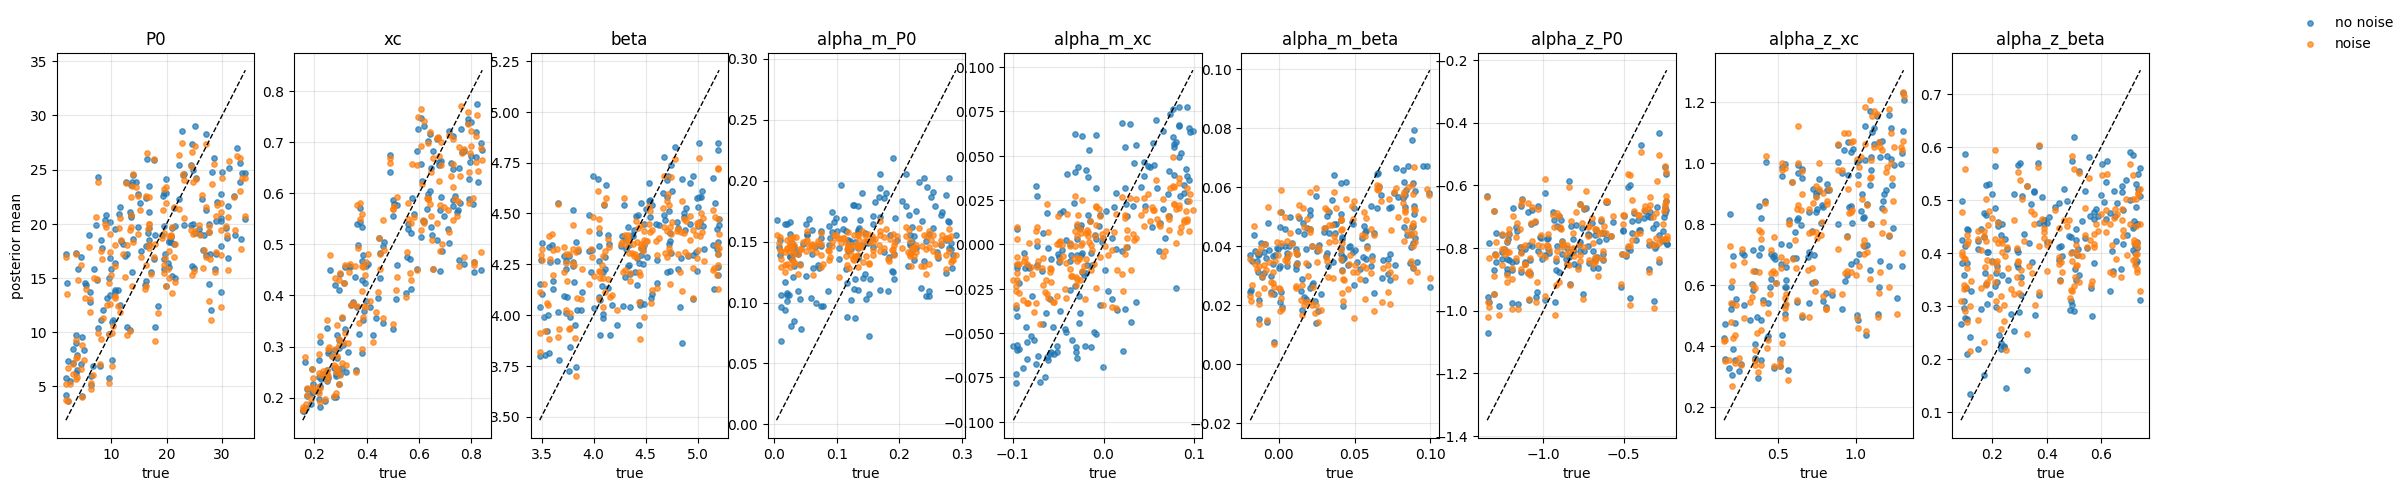

<Figure size 1200x800 with 0 Axes>

In [147]:
plot_recovery_scatter_two(
    validation_samples,
    validation_sampl_noise,
    split["theta_val"],
    labels=columns,
    dataset_labels=("no noise", "noise"),
    savefig_bool=True,
    savefig_name="recovery_clean_vs_noisy",
)

# Posterior contraction on validation set

In [34]:
def posterior_contraction(
    posterior_samples,
    prior_min,
    prior_max,
    labels=None,
):
    samples = to_tensor(posterior_samples)
    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)

    prior_delta = prior_max - prior_min
    posterior_std = samples.std(dim=1)

    contraction = posterior_std / prior_delta

    n_params = samples.shape[-1]

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    rows = []

    for j, name in enumerate(labels):
        rows.append({
            "parameter": name,
            "mean std / prior_delta": contraction[:, j].mean().item(),
            "median std / prior_delta": contraction[:, j].median().item(),
            "min std / prior_delta": contraction[:, j].min().item(),
            "max std / prior_delta": contraction[:, j].max().item(),
        })

    return pd.DataFrame(rows)

In [35]:
contraction_df = posterior_contraction(
    validation_samples,
    prior_low_cpu,
    prior_high_cpu,
    labels=columns,
)

contraction_df

,parameter,mean std / prior_delta,median std / prior_delta,min std / prior_delta,max std / prior_delta
0,P0,0.204230,0.203879,0.174140,0.225761
1,xc,0.145053,0.144013,0.107261,0.204462
2,beta,0.223397,0.224340,0.185001,0.243294
3,alpha_m_P0,0.218626,0.221315,0.153156,0.243686
4,alpha_m_xc,0.221329,0.221606,0.182746,0.238470
5,alpha_m_beta,0.220266,0.222087,0.175080,0.240491
6,alpha_z_P0,0.214729,0.216572,0.171451,0.248315
7,alpha_z_xc,0.157727,0.161718,0.095802,0.190369
8,alpha_z_beta,0.204736,0.206445,0.153711,0.232581


# diagnostics vs training-set size

In [72]:
def to_tensor(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().float()
    return torch.as_tensor(x, dtype=torch.float32)


def make_fixed_train_val_split(theta, x, n_val=174, seed=0):
    """
    Creates one fixed validation set.
    The remaining simulations form the training pool.
    """
    theta = to_tensor(theta)
    x = to_tensor(x)

    n_total = theta.shape[0]

    rng = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n_total, generator=rng)

    val_idx = indices[:n_val]
    train_pool_idx = indices[n_val:]

    return {
        "theta_train_pool": theta[train_pool_idx],
        "x_train_pool": x[train_pool_idx],
        "theta_val": theta[val_idx],
        "x_val": x[val_idx],
        "train_pool_idx": train_pool_idx,
        "val_idx": val_idx,
    }


def sample_posteriors(
    posterior,
    x_eval,
    num_posterior_samples=1000,
):
    """
    Returns posterior samples with shape:
    (n_eval, num_posterior_samples, n_params)
    """
    x_eval = to_tensor(x_eval)

    all_samples = []

    for i in range(x_eval.shape[0]):
        samples_i = posterior.sample(
            (num_posterior_samples,),
            x=x_eval[i],
            show_progress_bars=False,
        )
        all_samples.append(samples_i.detach().cpu())

    return torch.stack(all_samples, dim=0)

In [73]:
def compute_validation_metrics(
    posterior_samples,
    theta_true,
    prior_min,
    prior_max,
    labels=None,
    split_name="validation",
    n_train=None,
):
    """
    Computes the most useful SBI validation metrics per parameter.

    posterior_samples shape:
        (n_eval, n_posterior_samples, n_params)
    """

    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)
    prior_delta = prior_max - prior_min

    n_eval, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    posterior_mean = samples.mean(dim=1)
    posterior_median = samples.median(dim=1).values
    posterior_std = samples.std(dim=1)

    error = posterior_mean - theta_true
    abs_error = torch.abs(error)

    eps = 1e-12
    z_score = error / (posterior_std + eps)

    rows = []

    for j, label in enumerate(labels):
        theta_j = theta_true[:, j]
        samples_j = samples[:, :, j]

        # 68% interval
        low_68 = torch.quantile(samples_j, 0.16, dim=1)
        high_68 = torch.quantile(samples_j, 0.84, dim=1)
        coverage_68 = ((theta_j >= low_68) & (theta_j <= high_68)).float().mean()

        # 90% interval
        low_90 = torch.quantile(samples_j, 0.05, dim=1)
        high_90 = torch.quantile(samples_j, 0.95, dim=1)
        coverage_90 = ((theta_j >= low_90) & (theta_j <= high_90)).float().mean()

        # 95% interval
        low_95 = torch.quantile(samples_j, 0.025, dim=1)
        high_95 = torch.quantile(samples_j, 0.975, dim=1)
        coverage_95 = ((theta_j >= low_95) & (theta_j <= high_95)).float().mean()

        rows.append({
            "n_train": n_train,
            "split": split_name,
            "parameter": label,

            "bias / prior_delta": (error[:, j] / prior_delta[j]).mean().item(),
            "abs_bias / prior_delta": torch.abs((error[:, j] / prior_delta[j]).mean()).item(),

            "mean_abs_error / prior_delta": (abs_error[:, j] / prior_delta[j]).mean().item(),

            "mean_posterior_std / prior_delta": (posterior_std[:, j] / prior_delta[j]).mean().item(),
            "median_posterior_std / prior_delta": (posterior_std[:, j] / prior_delta[j]).median().item(),

            "rms_z_score": torch.sqrt(torch.mean(z_score[:, j] ** 2)).item(),
            "mean_abs_z_score": torch.abs(z_score[:, j]).mean().item(),

            "coverage_68": coverage_68.item(),
            "coverage_90": coverage_90.item(),
            "coverage_95": coverage_95.item(),

            "coverage_68_error": coverage_68.item() - 0.68,
            "coverage_90_error": coverage_90.item() - 0.90,
            "coverage_95_error": coverage_95.item() - 0.95,
        })

    return pd.DataFrame(rows)

In [74]:
def run_training_size_diagnostics(
    theta,
    x,
    prior_min,
    prior_max,
    train_sizes,
    n_val=174,
    labels=None,
    seed=0,
    num_posterior_samples=1000,
    evaluate_training_set=True,
    max_train_eval=100,
    train_kwargs=None,
):
    """
    Trains separate NPE models with different training-set sizes
    and evaluates metrics on a fixed validation set.

    Optionally also evaluates on part of the training set to diagnose overfitting.
    """

    theta = to_tensor(theta)
    x = to_tensor(x)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)

    prior = BoxUniform(
        low=prior_min,
        high=prior_max,
    )

    split = make_fixed_train_val_split(
        theta,
        x,
        n_val=n_val,
        seed=seed,
    )

    theta_train_pool = split["theta_train_pool"]
    x_train_pool = split["x_train_pool"]

    theta_val = split["theta_val"]
    x_val = split["x_val"]

    if labels is None:
        labels = [f"param_{i}" for i in range(theta.shape[1])]

    all_metrics = []
    posteriors = {}

    if train_kwargs is None:
        train_kwargs = {}

    for n_train in train_sizes:
        print(f"\nTraining NPE with n_train = {n_train}")

        if n_train > theta_train_pool.shape[0]:
            raise ValueError(
                f"n_train={n_train} is larger than available training pool "
                f"{theta_train_pool.shape[0]}"
            )

        theta_train = theta_train_pool[:n_train]
        x_train = x_train_pool[:n_train]

        inference = NPE(prior=prior)

        density_estimator = inference.append_simulations(
            theta_train,
            x_train,
        ).train(**train_kwargs)

        posterior = inference.build_posterior(density_estimator)
        posteriors[n_train] = posterior

        # validation metrics
        print("  Sampling validation posteriors...")
        val_samples = sample_posteriors(
            posterior,
            x_val,
            num_posterior_samples=num_posterior_samples,
        )

        val_metrics = compute_validation_metrics(
            posterior_samples=val_samples,
            theta_true=theta_val,
            prior_min=prior_min,
            prior_max=prior_max,
            labels=labels,
            split_name="validation",
            n_train=n_train,
        )

        all_metrics.append(val_metrics)

        # optional training-set metrics
        if evaluate_training_set:
            n_train_eval = min(max_train_eval, n_train)

            print(f"  Sampling training posteriors for {n_train_eval} examples...")

            train_samples = sample_posteriors(
                posterior,
                x_train[:n_train_eval],
                num_posterior_samples=num_posterior_samples,
            )

            train_metrics = compute_validation_metrics(
                posterior_samples=train_samples,
                theta_true=theta_train[:n_train_eval],
                prior_min=prior_min,
                prior_max=prior_max,
                labels=labels,
                split_name="training",
                n_train=n_train,
            )

            all_metrics.append(train_metrics)

    metrics_df = pd.concat(all_metrics, ignore_index=True)

    return metrics_df, posteriors, split

In [ ]:
train_sizes = [50, 100, 300, 500, 700, 850]

metrics_df, posteriors, split = run_training_size_diagnostics(
    theta=theta,
    x=x_mean,
    prior_min=prior_low_cpu,
    prior_max=prior_high_cpu,
    train_sizes=train_sizes,
    n_val=174,
    labels=columns,
    seed=1,
    num_posterior_samples=1000,
    evaluate_training_set=True,
    max_train_eval=100,
)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    diagnostics_dir = NOTEBOOK_SBI_OUTPUT_DIR / "training_size_diagnostics"
    diagnostics_dir.mkdir(parents=True, exist_ok=True)
    metrics_df.to_csv(diagnostics_dir / "training_size_metrics.csv", index=False)
    save_pickle(diagnostics_dir / "training_size_posteriors.pkl", posteriors)
    np.savez_compressed(
        diagnostics_dir / "training_size_split.npz",
        val_idx=split["val_idx"].detach().cpu().numpy(),
        train_pool_idx=split["train_pool_idx"].detach().cpu().numpy(),
        ell=ell.astype(np.float32),
        ell_unbinned=ell_unbinned.astype(np.float32),
        bin_counts=BINNING_SUMMARY["bin_counts"],
        bin_ell_min=BINNING_SUMMARY["bin_ell_min"],
        bin_ell_max=BINNING_SUMMARY["bin_ell_max"],
    )
    write_json(
        diagnostics_dir / "training_size_summary.json",
        {
            "dataset_path": str(DATASET_PATH),
            "train_sizes": [int(size) for size in train_sizes],
            "n_val": 174,
            "num_posterior_samples": 1000,
            "columns": list(columns),
            "n_ell": int(ell.size),
            "binning": binning_summary_to_jsonable(BINNING_SUMMARY),
        },
    )
    print(f"Saved training-size diagnostics to {diagnostics_dir}")


In [83]:
metrics_df

,n_train,split,parameter,bias / prior_delta,abs_bias / prior_delta,mean_abs_error / prior_delta,mean_posterior_std / prior_delta,median_posterior_std / prior_delta,rms_z_score,mean_abs_z_score,coverage_68,coverage_90,coverage_95,coverage_68_error,coverage_90_error,coverage_95_error
0,50,validation,P0,0.028256,0.028256,0.227200,0.256054,0.255681,1.028903,0.887485,0.620690,0.902299,0.959770,-0.059310,0.002299,0.009770
1,50,validation,xc,0.066318,0.066318,0.204450,0.203797,0.208661,1.154982,0.999290,0.505747,0.816092,0.896552,-0.174253,-0.083908,-0.053448
2,50,validation,beta,0.039745,0.039745,0.265721,0.251156,0.251335,1.196653,1.058754,0.482759,0.821839,0.890805,-0.197241,-0.078161,-0.059195
3,50,validation,alpha_m_P0,-0.006897,0.006897,0.244749,0.233006,0.230504,1.224469,1.051071,0.494253,0.810345,0.885057,-0.185747,-0.089655,-0.064943
4,50,validation,alpha_m_xc,-0.023326,0.023326,0.236655,0.232695,0.231100,1.208129,1.023299,0.551724,0.798851,0.867816,-0.128276,-0.101149,-0.082184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,850,training,alpha_m_xc,0.013937,0.013937,0.213618,0.213657,0.215306,1.171299,1.000074,0.560000,0.820000,0.860000,-0.120000,-0.080000,-0.090000
104,850,training,alpha_m_beta,0.043547,0.043547,0.229722,0.225254,0.226215,1.199049,1.016515,0.510000,0.770000,0.850000,-0.170000,-0.130000,-0.100000
105,850,training,alpha_z_P0,-0.007965,0.007965,0.240943,0.221361,0.221776,1.282902,1.091818,0.480000,0.720000,0.870000,-0.200000,-0.180000,-0.080000
106,850,training,alpha_z_xc,-0.027630,0.027630,0.188402,0.187434,0.190183,1.199068,1.007430,0.530000,0.800000,0.890000,-0.150000,-0.100000,-0.060000


In [84]:
def plot_aggregate_metrics_vs_training_size(metrics_df):
    metric_names = [
        "mean_abs_error / prior_delta",
        "abs_bias / prior_delta",
        "mean_posterior_std / prior_delta",
        "rms_z_score",
        "coverage_68",
        "coverage_90",
    ]

    for metric in metric_names:
        plt.figure(figsize=(7, 5))

        for split_name in metrics_df["split"].unique():
            d = metrics_df[metrics_df["split"] == split_name]

            agg = (
                d.groupby("n_train")[metric]
                .mean()
                .reset_index()
                .sort_values("n_train")
            )

            plt.plot(
                agg["n_train"],
                agg[metric],
                marker="o",
                label=split_name,
            )

        if metric == "coverage_68":
            plt.axhline(0.68, ls="--", color="black", label="ideal 0.68")
        if metric == "coverage_90":
            plt.axhline(0.90, ls="--", color="black", label="ideal 0.90")
        if metric == "rms_z_score":
            plt.axhline(1.0, ls="--", color="black", label="ideal 1")

        plt.xscale("log")
        plt.xlabel("Number of training simulations")
        plt.ylabel(metric)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

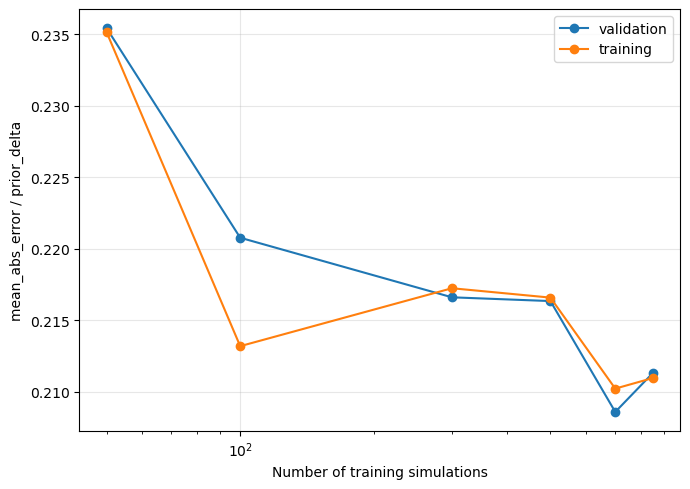

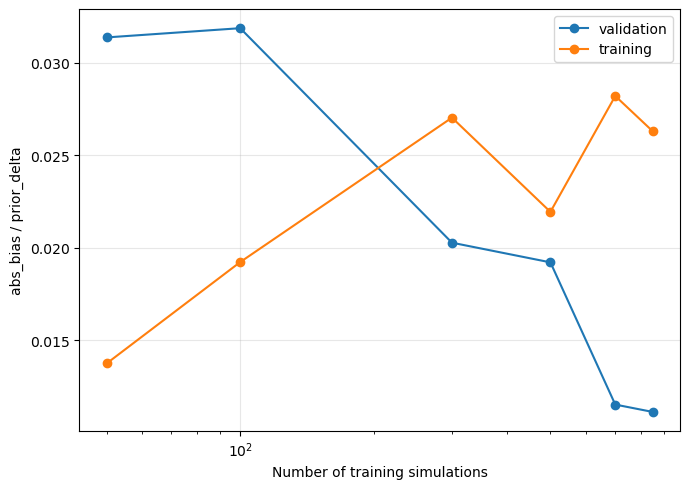

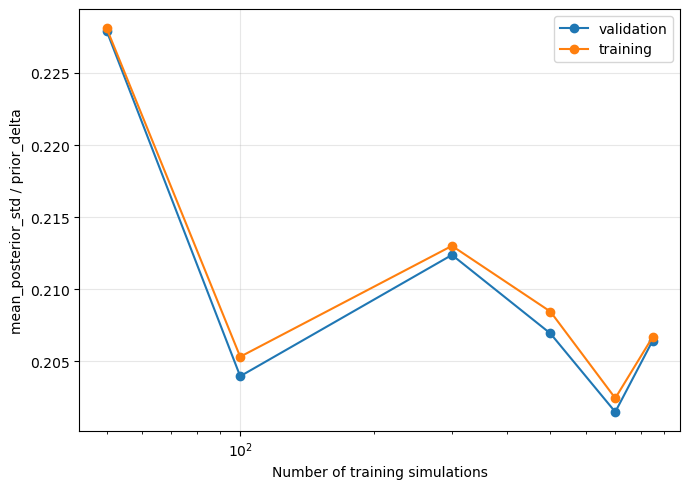

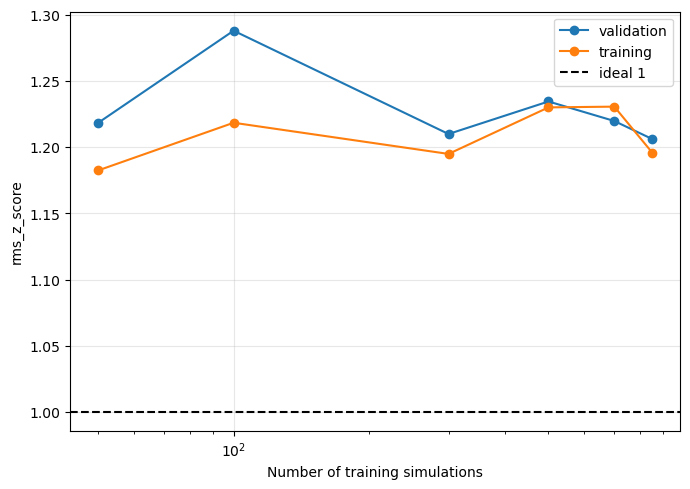

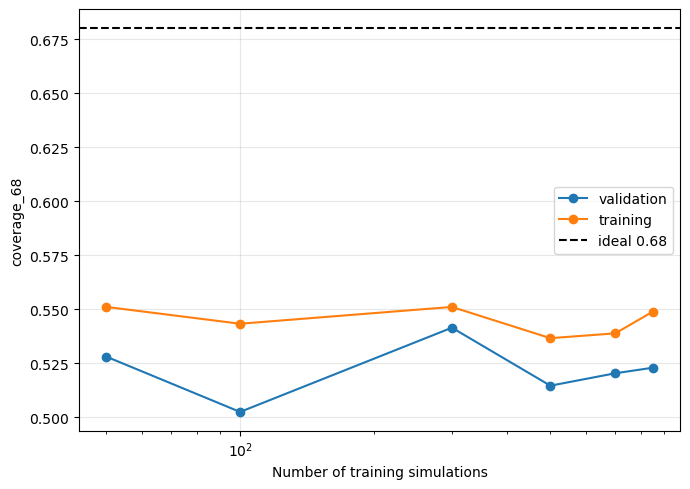

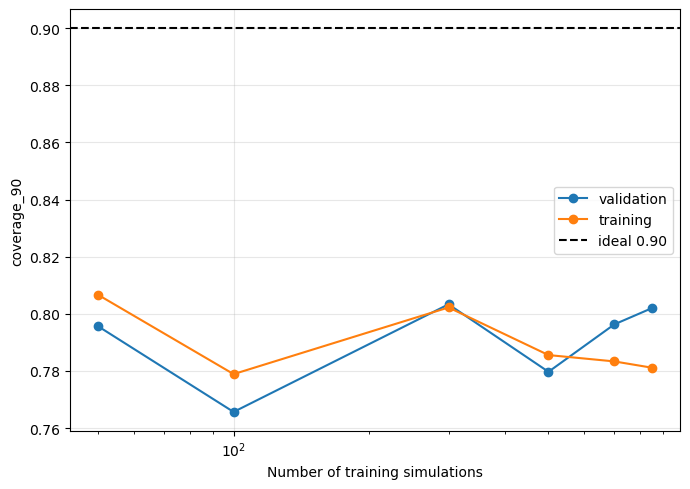

In [85]:
plot_aggregate_metrics_vs_training_size(metrics_df)

In [86]:
def plot_parameter_metric_vs_training_size(
    metrics_df,
    metric,
    split_name="validation",
):
    d = metrics_df[metrics_df["split"] == split_name].copy()

    params = d["parameter"].unique()

    plt.figure(figsize=(9, 6))

    for p in params:
        dp = d[d["parameter"] == p].sort_values("n_train")

        plt.plot(
            dp["n_train"],
            dp[metric],
            marker="o",
            label=p,
        )

    if metric == "coverage_68":
        plt.axhline(0.68, ls="--", color="black", label="ideal 0.68")
    if metric == "coverage_90":
        plt.axhline(0.90, ls="--", color="black", label="ideal 0.90")
    if metric == "rms_z_score":
        plt.axhline(1.0, ls="--", color="black", label="ideal 1")

    plt.xscale("log")
    plt.xlabel("Number of training simulations")
    plt.ylabel(metric)
    plt.title(f"{metric} on {split_name} set")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

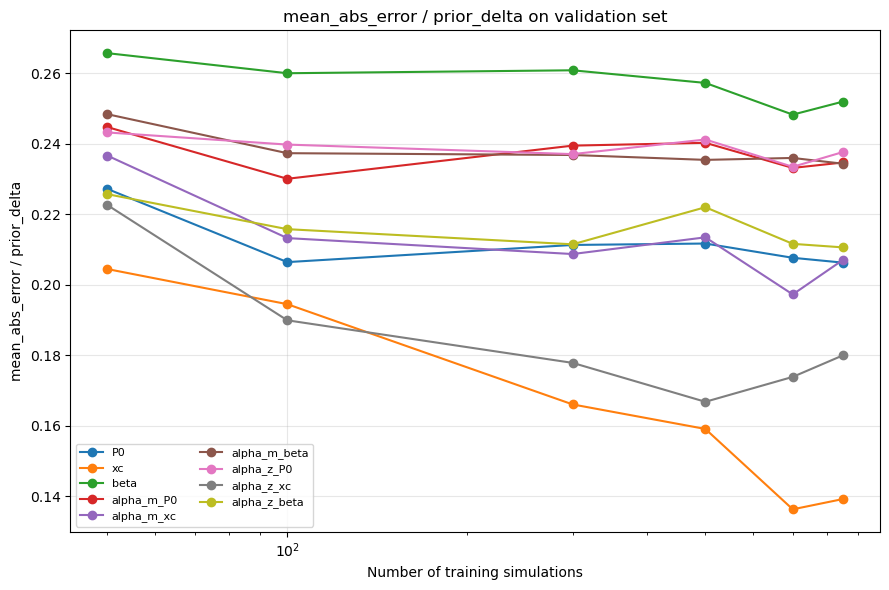

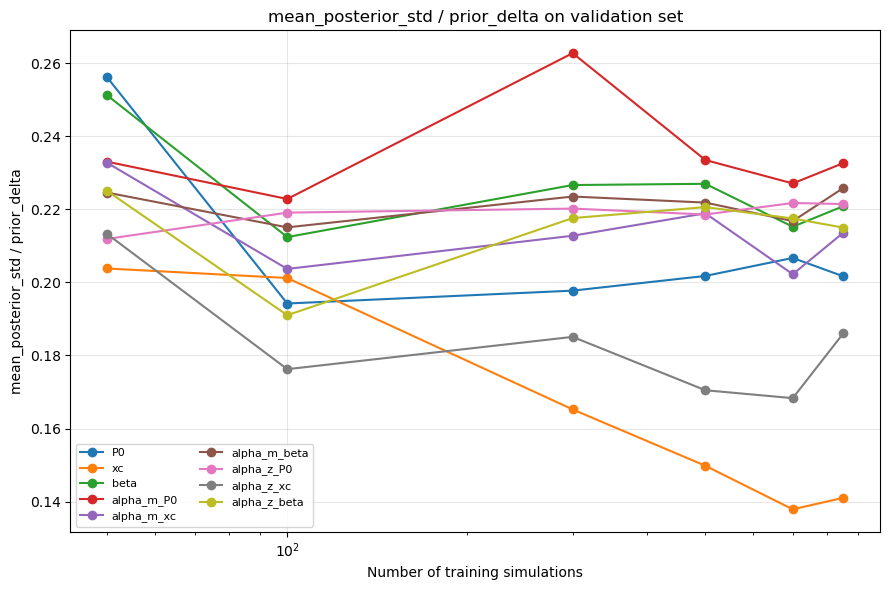

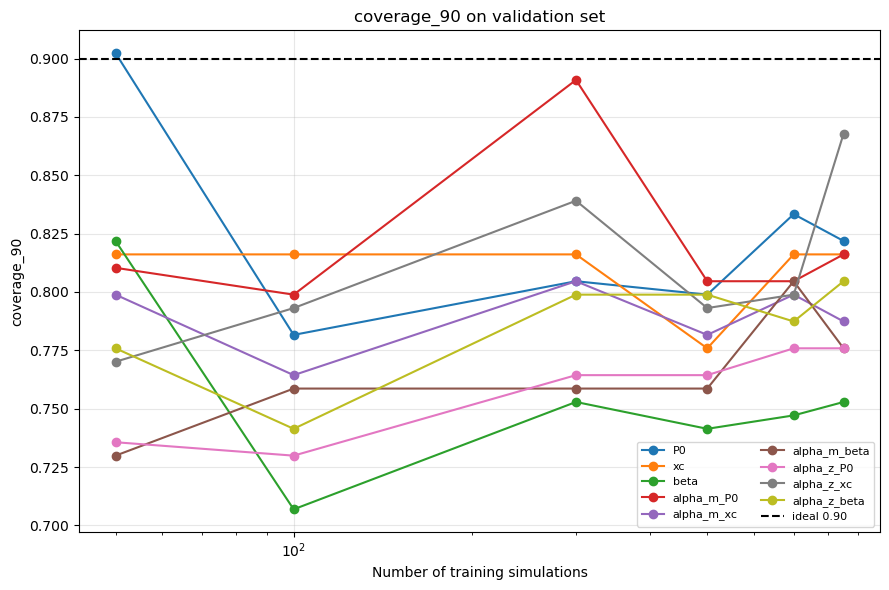

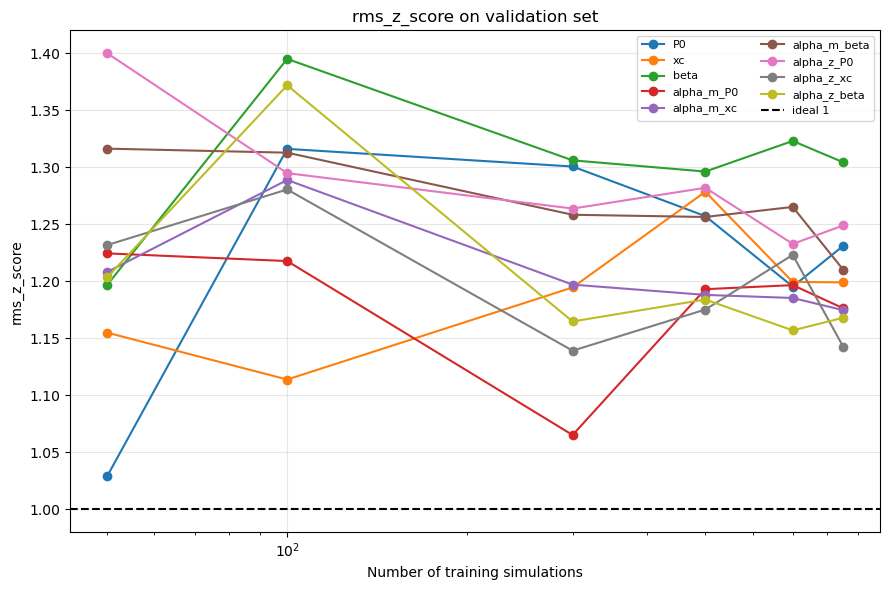

In [87]:
plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="mean_abs_error / prior_delta",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="mean_posterior_std / prior_delta",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="coverage_90",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="rms_z_score",
    split_name="validation",
)